# 05 — VAR Baseline

## Objetivo

Estimar o modelo VAR de referência (baseline) para análise dos efeitos da 
política monetária sobre PIB (proxy: IBC-Br) e inflação (IPCA) no Brasil, 
no período 2003-2025 em frequência mensal.

Este é o coração do projeto. Os resultados deste notebook serão comparados 
com:

- A monografia original (modelo VAR trimestral 2002-2024)
- O BVAR com Minnesota prior (notebook 06)
- O VAR com sign restrictions (notebook 07)

## Decisões herdadas dos blocos anteriores

| Item | Decisão | Origem |
|------|---------|--------|
| Janela temporal | 2003-01 a 2025-12 (276 obs mensais) | Bloco 3 |
| Tratamento da pandemia | Dummies para mar-set 2020 | Bloco 3 |
| Especificação | VAR em diferenças (não VECM) | Bloco 4 |
| Ordem de integração das séries | 8 séries I(1), IPCA I(0) | Bloco 4 |
| Dummies de quebra estrutural | Selic 2017, cambio/indústria 2014, crédito 2015 | Bloco 4 |

## Análises de robustez planejadas

Conforme o princípio de parcimônia adotado, as seguintes especificações 
alternativas ficam registradas para avaliação futura:

| # | Alternativa | Origem |
|---|-------------|--------|
| R1 | Modelo incluindo crédito total (canal de crédito) | Definição de variáveis |
| R2 | Produção industrial no lugar do IBC-Br | Definição de variáveis |
| R3 | Janela excluindo 2003-2004 (resíduos da crise pré-Lula) | Bloco 4 |
| R4 | Selic com duas dummies de quebra (2017 + 2021) | Análise visual |
| R5 | VECM para o subsistema de demanda por moeda | Bloco 4 |

## Estrutura do notebook

1. Construção das variáveis finais (diferenças)
2. Construção das dummies de quebra estrutural
3. Definição do conjunto de variáveis
4. Ordenação de Cholesky
5. Seleção de defasagens
6. Estimação e diagnósticos
7. IRFs e decomposição da variância
8. Comparação com a monografia

## 1. Construção das variáveis finais

### Decisão de modelagem

Conjunto final de 6 variáveis para o VAR baseline:

| Variável | Transformação | Papel no modelo |
|----------|--------------|-----------------|
| `ln_commodities` | Primeira diferença | Controle exógeno externo |
| `ln_ibcbr` | Primeira diferença | Atividade econômica |
| `ipca` | Nível | Inflação realizada (I(0)) |
| `exp_ipca_12m` | Primeira diferença | Expectativa forward-looking |
| `selic` | Primeira diferença | Instrumento de política monetária |
| `ln_cambio` | Primeira diferença | Variável cambial |

**Diferenças vs nível:** todas as séries I(1) entram em primeira diferença 
(ver Bloco 4 para fundamentação). O IPCA, classificado como I(0), entra 
em nível.

**Interpretação econômica das diferenças do log:** $\Delta \ln(y_t) = 
\ln(y_t) - \ln(y_{t-1}) \approx$ taxa de crescimento mensal de $y_t$ 
(para valores pequenos). Assim, "$\Delta$ ln_ibcbr" representa 
aproximadamente a taxa de crescimento mensal do indicador de atividade.

### Variáveis fora do baseline (análises de robustez futuras)

- `ln_prod_industrial`: redundante com IBC-Br
- `ln_credito_total`: canal de crédito específico (modelo de robustez)
- `ln_m1`: endógeno sob regime de metas com taxa de juros como instrumento

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROCESSED = Path('../data/processed')

# Carrega o dataset tratado do Bloco 3
df = pd.read_csv(
    DATA_PROCESSED / 'series_tratadas.csv',
    index_col=0,
    parse_dates=True
)

print(f"Dataset carregado: {df.shape}")
print(f"Período: {df.index.min().strftime('%Y-%m')} a {df.index.max().strftime('%Y-%m')}")

Dataset carregado: (276, 16)
Período: 2003-01 a 2025-12


In [8]:
# Construção das variáveis finais do modelo

# Séries que entram em primeira diferença (todas as I(1))
series_diff = [
    'ln_commodities',
    'ln_ibcbr',
    'exp_ipca_12m',
    'selic',
    'ln_cambio',
]

# Séries que entram em nível (I(0))
series_nivel = [
    'ipca',
]

# Constrói o DataFrame do modelo
df_modelo = pd.DataFrame(index=df.index)

# Primeiras diferenças (prefixo "d_" para deixar claro)
for col in series_diff:
    df_modelo[f'd_{col}'] = df[col].diff()

# Séries em nível mantêm o nome original
for col in series_nivel:
    df_modelo[col] = df[col]

# Adiciona as dummies de pandemia (que já existem no df)
dummies_pandemia = [c for c in df.columns if c.startswith('dummy_covid_')]
for col in dummies_pandemia:
    df_modelo[col] = df[col]

print(f"\nDataFrame do modelo:")
print(f"Shape: {df_modelo.shape}")
print(f"\nColunas:")
for c in df_modelo.columns:
    print(f"  - {c}")


DataFrame do modelo:
Shape: (276, 13)

Colunas:
  - d_ln_commodities
  - d_ln_ibcbr
  - d_exp_ipca_12m
  - d_selic
  - d_ln_cambio
  - ipca
  - dummy_covid_2020_03
  - dummy_covid_2020_04
  - dummy_covid_2020_05
  - dummy_covid_2020_06
  - dummy_covid_2020_07
  - dummy_covid_2020_08
  - dummy_covid_2020_09


In [9]:
# Verificação da Etapa 5.1
print("=" * 70)
print("VERIFICAÇÃO DO df_modelo")
print("=" * 70)

print(f"\nShape: {df_modelo.shape}")
print(f"\nPeríodo: {df_modelo.index.min().strftime('%Y-%m')} a {df_modelo.index.max().strftime('%Y-%m')}")

# Variáveis em diferença
vars_diff = [c for c in df_modelo.columns if c.startswith('d_')]
print(f"\nVariáveis em diferença ({len(vars_diff)}):")
for v in vars_diff:
    print(f"  - {v}")

# Variáveis em nível
vars_nivel = [c for c in df_modelo.columns if c == 'ipca']
print(f"\nVariáveis em nível ({len(vars_nivel)}):")
for v in vars_nivel:
    print(f"  - {v}")

# Dummies de pandemia
dummies = [c for c in df_modelo.columns if c.startswith('dummy_covid_')]
print(f"\nDummies de pandemia ({len(dummies)}):")
for d in dummies:
    print(f"  - {d}")

print(f"\nNaNs por coluna (esperado: 1 NaN em cada série diferenciada, na primeira linha):")
print(df_modelo.isna().sum())

print(f"\nPrimeiras 3 linhas:")
print(df_modelo.head(3))

VERIFICAÇÃO DO df_modelo

Shape: (276, 13)

Período: 2003-01 a 2025-12

Variáveis em diferença (5):
  - d_ln_commodities
  - d_ln_ibcbr
  - d_exp_ipca_12m
  - d_selic
  - d_ln_cambio

Variáveis em nível (1):
  - ipca

Dummies de pandemia (7):
  - dummy_covid_2020_03
  - dummy_covid_2020_04
  - dummy_covid_2020_05
  - dummy_covid_2020_06
  - dummy_covid_2020_07
  - dummy_covid_2020_08
  - dummy_covid_2020_09

NaNs por coluna (esperado: 1 NaN em cada série diferenciada, na primeira linha):
d_ln_commodities       1
d_ln_ibcbr             1
d_exp_ipca_12m         1
d_selic                1
d_ln_cambio            1
ipca                   0
dummy_covid_2020_03    0
dummy_covid_2020_04    0
dummy_covid_2020_05    0
dummy_covid_2020_06    0
dummy_covid_2020_07    0
dummy_covid_2020_08    0
dummy_covid_2020_09    0
dtype: int64

Primeiras 3 linhas:
            d_ln_commodities  d_ln_ibcbr  d_exp_ipca_12m  d_selic  \
Date                                                                
2003-01-01

## 2. Visualização das variáveis do modelo

Antes de construir dummies de quebra estrutural, visualizamos as séries no 
formato que entrarão no modelo VAR. Este passo é importante porque:

1. **Confirmação visual da estacionariedade:** as séries em diferença devem 
   oscilar em torno de média estável (idealmente próxima de zero ou um valor 
   constante), sem tendência aparente.

2. **Identificação de mudanças de drift:** se a média da diferença muda em 
   algum ponto da série, isso é evidência de **mudança de regime** que 
   deve ser modelada via dummy de degrau (não de pulso).

3. **Identificação de outliers pontuais:** se há valores extremos isolados 
   (além do trauma da pandemia já tratado), podem indicar pontos que 
   precisam de tratamento adicional.

4. **Decisão sobre tipo de dummy de quebra:**
   - Se a mudança é **gradual ao longo de meses** → dummy de degrau
   - Se a mudança é **um único choque pontual** → dummy de pulso

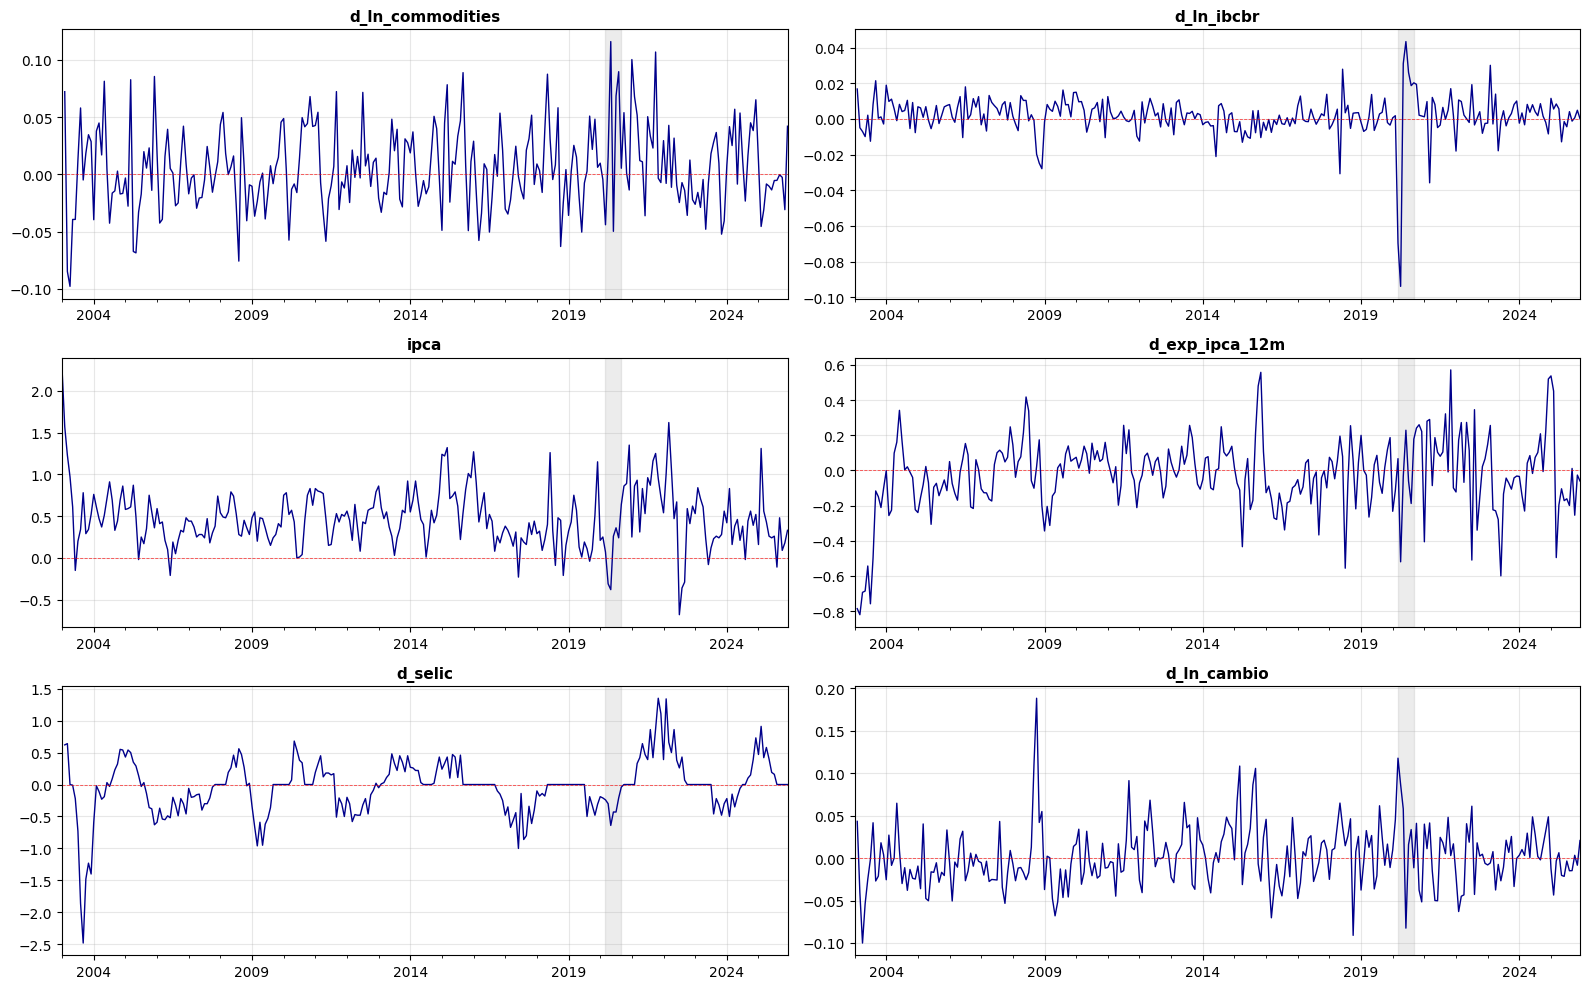

In [10]:
# Variáveis do modelo (em diferença ou nível)
vars_modelo = [
    'd_ln_commodities',
    'd_ln_ibcbr',
    'ipca',  # única em nível
    'd_exp_ipca_12m',
    'd_selic',
    'd_ln_cambio',
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(vars_modelo):
    ax = axes[i]
    df_modelo[col].plot(ax=ax, color='darkblue', linewidth=1)
    
    # Linha horizontal em zero como referência
    ax.axhline(y=0, color='red', linewidth=0.6, linestyle='--', alpha=0.7)
    
    # Sombreia o período da pandemia para referência
    ax.axvspan('2020-03', '2020-09', alpha=0.15, color='gray')
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/05_variaveis_modelo.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.1 Análise visual das variáveis do modelo

Inspeção das 6 séries no formato em que entrarão no VAR (cinco em primeira 
diferença, IPCA em nível). A faixa cinza marca o período da pandemia 
(mar-set 2020), já tratado por dummies.

#### d_ln_commodities

Oscila em torno de zero ao longo de todo o período, confirmando 
estacionariedade. Observa-se **aumento da volatilidade a partir de 2019-2020**, 
sustentado até 2025 — efeito combinado do fim do superciclo de commodities, 
choques pós-pandemia e guerra na Ucrânia. A maior variância no período recente 
é parte legítima da dinâmica e não demanda tratamento adicional, mas deve ser 
considerada na interpretação dos resultados.

#### d_ln_ibcbr

Oscila em torno de zero, com o **outlier brutal da pandemia** claramente 
visível (queda de ~9% em abril/2020, recuperação nos meses seguintes). Sem o 
tratamento via dummies de pandemia, esse ponto dominaria a estimação. Fora 
da pandemia, o comportamento é estacionário e bem-comportado.

#### ipca

Única série em nível. Estacionária em torno de média positiva (~0,5% ao mês), 
com **outlier no início da amostra** (janeiro/2003, ~2%), resíduo da crise de 
credibilidade pré-Lula. Como o IPCA entra em nível, esse ponto permanece nos 
dados. Decisão: **aceitar o outlier no baseline** (apenas 1 observação em 276); 
o efeito será avaliado na análise de robustez que exclui 2003-2004 (R3).

#### d_exp_ipca_12m

Comportamento estacionário com **drift levemente positivo a partir de 2020-2021**: 
sucessão de picos positivos persistentes (2021, 2022, 2024) reflete a 
**desancoragem parcial das expectativas** pós-pandemia. Decisão: **não incluir 
dummy de quebra** para esta série — a desancoragem é fenômeno econômico 
relevante que o modelo deve capturar endogenamente, especialmente o feedback 
entre expectativa e Selic.

#### d_selic

A série revela **três regimes distintos**:

1. **2003-2017**: oscilação em torno de zero (stop-and-go monetário do período)
2. **2017-2020**: média negativa (ciclo de cortes, Selic atingindo mínimos 
   históricos de ~2% a.a.)
3. **2021-2025**: ciclo de aperto-afrouxamento-aperto dentro do regime 
   pós-pandemia, com média próxima de zero mas alta volatilidade

Há ainda um **outlier expressivo em 2003** (resolução da incerteza sobre a 
posse de Lula). A transição mais estrutural é a de 2017 (entrada no regime de 
juros baixos). Decisão: **uma dummy de quebra em 2017-01** no baseline; a 
possível segunda quebra (~2021) fica registrada como robustez (R4).

#### d_ln_cambio

Sem mudança brusca de média, mas há **alteração sutil de regime**: até ~2012-2013 
predominam valores negativos (apreciação do real); a partir de 2013-2014 os 
valores positivos tornam-se mais frequentes (depreciação estrutural). Dois 
**outliers** destacam-se: a crise financeira global (2008-2009) e a pandemia 
(2020). A mudança de regime, ainda que sutil, é consistente com a análise do 
Bloco 3. Decisão: **dummy de quebra de degrau em 2014-09**.

### 2.2 Síntese das decisões

| Variável | Tratamento de quebra | Justificativa |
|----------|---------------------|---------------|
| `d_selic` | Dummy de degrau em 2017-01 | Entrada no regime de juros baixos |
| `d_ln_cambio` | Dummy de degrau em 2014-09 | Mudança de regime cambial |
| `d_exp_ipca_12m` | Nenhuma | Desancoragem é dinâmica endógena relevante |
| `ipca` | Nenhuma | Outlier de 2003 aceito; avaliado em robustez (R3) |
| `d_ln_commodities` | Nenhuma | Maior variância pós-2020 é parte da dinâmica |
| `d_ln_ibcbr` | Nenhuma | Pandemia já tratada por dummies dedicadas |

## 3. Quebras estruturais — decisão revisada

### Reavaliação

O Bloco 4 identificou quebras estruturais no **nível** de `selic` e 
`ln_cambio` (mudança de patamar). A intenção inicial era incluir dummies 
de degrau para capturar essas quebras.

A inspeção visual das séries em diferença (Etapa 2) revelou que essa 
abordagem é **conceitualmente inadequada**:

- A quebra estrutural ocorria no **nível** das séries (mudança permanente 
  de patamar).
- O modelo VAR é especificado em **primeira diferença**.
- A operação de diferenciação **absorve mudanças de patamar**: uma quebra 
  de nível se manifesta na série diferenciada como poucos pontos atípicos 
  no período de transição, não como mudança de regime permanente.
- Dummies de degrau capturam mudança de *drift* (média da série 
  diferenciada). Como `d_selic` e `d_ln_cambio` oscilam em torno de média 
  aproximadamente constante (≈ 0) em todo o período, não há *drift* a 
  capturar.

### Decisão

**Não incluir dummies de quebra estrutural no baseline.** As séries 
diferenciadas absorvem naturalmente as quebras de nível como eventos 
pontuais de transição, que o VAR trata como parte da dinâmica.

### Registro para robustez futura (R4 revisado)

Testar dummies de **pulso** (não degrau) nos meses específicos de transição 
de regime — final de 2016 para a Selic, segundo semestre de 2014 para o 
câmbio — para verificar se a captura desses pontos de transição altera 
materialmente os resultados.

### Princípio metodológico

A correção ilustra a importância da inspeção visual antes da estimação: 
a decisão tomada com base apenas nos testes do Bloco 4 (quebra no nível) 
não se traduziu corretamente para a especificação em diferenças. O erro 
foi detectado visualmente e corrigido.

In [11]:
# Remove as dummies de quebra estrutural (decisão revisada — ver Markdown acima)
colunas_quebra = ['dummy_quebra_selic', 'dummy_quebra_cambio']

for col in colunas_quebra:
    if col in df_modelo.columns:
        df_modelo = df_modelo.drop(columns=col)
        print(f"Removida: {col}")
    else:
        print(f"Não encontrada (já removida ou nunca criada): {col}")

print(f"\nShape atual do df_modelo: {df_modelo.shape}")
print(f"\nColunas atuais:")
for c in df_modelo.columns:
    print(f"  - {c}")

Não encontrada (já removida ou nunca criada): dummy_quebra_selic
Não encontrada (já removida ou nunca criada): dummy_quebra_cambio

Shape atual do df_modelo: (276, 13)

Colunas atuais:
  - d_ln_commodities
  - d_ln_ibcbr
  - d_exp_ipca_12m
  - d_selic
  - d_ln_cambio
  - ipca
  - dummy_covid_2020_03
  - dummy_covid_2020_04
  - dummy_covid_2020_05
  - dummy_covid_2020_06
  - dummy_covid_2020_07
  - dummy_covid_2020_08
  - dummy_covid_2020_09


## 4. Conjunto final de variáveis do modelo

Consolidando as decisões dos blocos anteriores e das etapas 1 a 3 deste bloco:

### Variáveis endógenas (6)

Estas são as variáveis cuja dinâmica conjunta o VAR vai modelar — cada uma 
responde a choques nas outras.

| Variável | Forma | Papel econômico |
|----------|-------|-----------------|
| `d_ln_commodities` | 1ª diferença do log | Choque externo (Brasil é tomador de preços) |
| `d_ln_ibcbr` | 1ª diferença do log | Atividade econômica (proxy mensal do PIB) |
| `ipca` | Nível | Inflação realizada |
| `d_exp_ipca_12m` | 1ª diferença | Expectativa de inflação (forward-looking) |
| `d_selic` | 1ª diferença | Instrumento de política monetária |
| `d_ln_cambio` | 1ª diferença do log | Variável cambial |

### Variáveis exógenas (7)

Não respondem a choques do sistema, mas afetam as endógenas.

| Variável | Tipo | Função |
|----------|------|--------|
| `dummy_covid_2020_03` a `dummy_covid_2020_09` | Pulso | Isolar choque agudo da pandemia |

### Sem dummies de quebra estrutural

Conforme correção metodológica da Etapa 3: as quebras estruturais 
identificadas no Bloco 4 ocorrem no nível das séries; a diferenciação 
absorve essas quebras como eventos pontuais, dispensando dummies de degrau.

### Dimensionamento do modelo

Com 6 variáveis endógenas e 7 exógenas, em amostra de 275 observações 
(janeiro/2003 a dezembro/2025, sem o primeiro mês perdido na diferenciação), 
o modelo é razoavelmente dimensionado:

- **VAR(2):** 6 × (6 × 2 + 1 + 7) = 120 coeficientes estimados (20 por equação)
- **VAR(4):** 6 × (6 × 4 + 1 + 7) = 192 coeficientes estimados (32 por equação)
- **VAR(6):** 6 × (6 × 6 + 1 + 7) = 264 coeficientes estimados (44 por equação)

Com VAR(4) temos ~8,6 observações por parâmetro estimado. Confortável. VAR(6) 
já fica apertado.

In [13]:
# Define o conjunto final de variáveis
variaveis_endogenas = [
    'd_ln_commodities',   # 1 — mais exógena
    'd_ln_ibcbr',         # 2
    'ipca',               # 3
    'd_exp_ipca_12m',     # 4
    'd_selic',            # 5
    'd_ln_cambio',        # 6 — mais endógena
]

variaveis_exogenas = [c for c in df_modelo.columns if c.startswith('dummy_covid_')]

# Verificação
print(f"Variáveis endógenas ({len(variaveis_endogenas)}):")
for v in variaveis_endogenas:
    print(f"  - {v}")

print(f"\nVariáveis exógenas ({len(variaveis_exogenas)}):")
for v in variaveis_exogenas:
    print(f"  - {v}")

# Confirma que tudo está no df_modelo
todas_vars = variaveis_endogenas + variaveis_exogenas
faltantes = set(todas_vars) - set(df_modelo.columns)
extras = set(df_modelo.columns) - set(todas_vars)

if faltantes:
    print(f"\n⚠ Faltantes em df_modelo: {faltantes}")
if extras:
    print(f"\n⚠ Extras em df_modelo (não vão ser usados): {extras}")
if not faltantes and not extras:
    print(f"\n✓ df_modelo contém exatamente as variáveis necessárias")

Variáveis endógenas (6):
  - d_ln_commodities
  - d_ln_ibcbr
  - ipca
  - d_exp_ipca_12m
  - d_selic
  - d_ln_cambio

Variáveis exógenas (7):
  - dummy_covid_2020_03
  - dummy_covid_2020_04
  - dummy_covid_2020_05
  - dummy_covid_2020_06
  - dummy_covid_2020_07
  - dummy_covid_2020_08
  - dummy_covid_2020_09

✓ df_modelo contém exatamente as variáveis necessárias


## 5. Ordenação de Cholesky

### Decisão

| Posição | Variável | Justificativa |
|:---:|----------|---------------|
| 1 | `d_ln_commodities` | Variável exógena externa: Brasil é tomador de preços internacionais |
| 2 | `d_ln_ibcbr` | Atividade econômica com rigidez quantitativa (ajuste de produção e emprego é lento) |
| 3 | `ipca` | Rigidez nominal novo-keynesiana: preços ajustam contemporaneamente a choques de oferta e demanda, não à política monetária |
| 4 | `d_exp_ipca_12m` | Forward-looking: mercado forma expectativa observando preços, atividade e commodities; antecede decisão do BC |
| 5 | `d_selic` | Instrumento de política: BC reage à expectativa (não ao IPCA realizado) sob regime de metas |
| 6 | `d_ln_cambio` | Variável financeira de alta liquidez: absorve contemporaneamente todas as outras |

### Implicações da ordenação para identificação dos choques

A decomposição de Cholesky impõe estrutura recursiva contemporânea:

- A **posição 1 (commodities)** não responde no mesmo mês a nenhuma outra variável — apenas a choques globais
- O **choque monetário identificado (Selic, posição 5)** é o componente da variação da Selic que **não é explicado** por commodities, IBC-Br, IPCA ou expectativa de inflação contemporâneos. Ou seja, é o componente "surpresa" da decisão do Copom relativa às condições macroeconômicas observadas
- O **câmbio (posição 6)** responde contemporaneamente a todas as outras, refletindo sua natureza de ativo financeiro líquido em frequência mensal

### Diferenças críticas em relação à monografia

| Aspecto | Monografia | Projeto atual |
|---------|-----------|---------------|
| Expectativa de inflação | Ausente do modelo | Posição 4 (antes da Selic) |
| Posição relativa IPCA-Selic | IPCA antes, sem expectativa entre | IPCA → expectativa → Selic |
| Câmbio | Tratado como exógeno | Endógeno (posição 6) |
| Commodities | Tratado como exógeno | Endógena (posição 1) |

A inclusão da expectativa de inflação **entre IPCA e Selic** é a mudança 
metodológica mais importante: ela permite identificar o choque monetário 
"limpo" via Cholesky, abrindo caminho para resolver o *price puzzle* 
identificado na monografia.

### Limitação reconhecida (crítica de Cooley-LeRoy, 1985)

A ordenação de Cholesky depende de hipóteses de identificação econômicas, 
não testadas empiricamente. Diferentes ordenações geram diferentes IRFs. Por 
essa razão:

- A ordenação adotada é defendida com base em mecanismo econômico, não 
  conveniência computacional
- O Bloco 7 implementará **sign restrictions** como abordagem alternativa de 
  identificação, mais robusta a hipóteses recursivas arbitrárias
- A robustez à ordenação será verificada permutando posições limítrofes 
  (ex: trocar posições 4 e 5) em análise de sensibilidade